<a href="https://colab.research.google.com/github/ramjulopez-prog/final-project/blob/main/lopez_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
df = pd.read_csv('/content/Walmart.csv')

# ***Business Understanding***

*The organization used in my  project is a retail company similar to Walmart that operates multiple stores in different locations. The company sells a wide range of products and collects weekly sales data to monitor store performance and customer demand.*

*The company I picked has trouble predicting weekly sales accurately. Forecast inaccuracies can lead to inventory shortages, overstocking, higher operating costs, and lost sales opportunities. Data driven decision making is important because it allows the company to plan inventory better, optimize staffing, and prepare for seasonal demand fluctuations.*

# ***Business-related questions***

***Are there seasonal or monthly sales patterns that affect business performance?***


***Can machine learning models accurately predict weekly sales?***

***Are there specific periods with unusually high or low sales?***


***Which factors most influence weekly sales?***

***Are the model predictions reliable enough for business decision-making?***

# ***Data Understanding***

*In this project we use the Walmart Sales Dataset. It contains historical weekly sales data for a number of Walmart stores and economic and seasonal variables like temperature, fuel price, CPI, unemployment rate and holiday information. The variable to be predicted is Weekly_Sales.*

In [ ]:
import pandas as pd

df = pd.read_csv('//content/Walmart.csv')

### ***DISPLAYING***

In [ ]:
df.shape

(6435, 8)

*The shape of the dataset shows the total number of rows and columns. This helps determine the size of the dataset and whether it contains enough observations for machine learning analysis.*

In [ ]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05/02/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/02/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05/03/2010,1554806.68,0,46.50,2.625,211.350143,8.106


*The first few rows of the dataset were displayed to understand the structure, column names, and sample values of the data.*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


*The info() function was used to inspect the data types, number of non-null values, and overall structure of the dataset.*

In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


*The describe() function provides statistical summaries such as mean, minimum, maximum, and standard deviation for numerical variables in the dataset.*

***CHECKING***

In [ ]:
df.isna().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


*Missing values were checked to identify incomplete records that could affect machine learning model performance and prediction accuracy.*

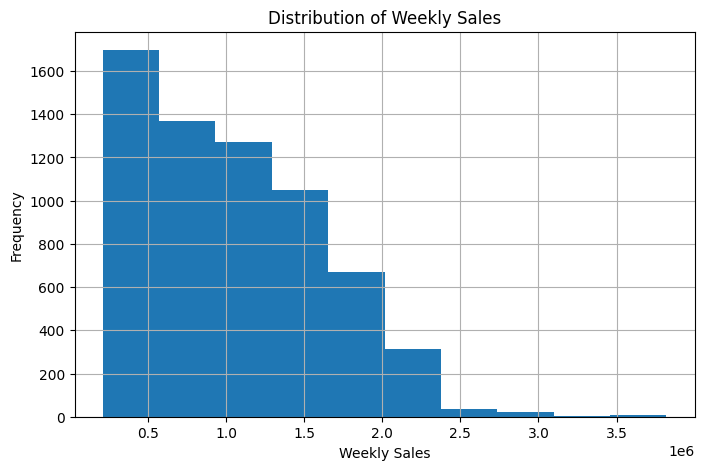

In [ ]:
import matplotlib.pyplot as plt

df['Weekly_Sales'].hist(figsize=(8,5))

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

*The histogram was used to visualize the distribution of Weekly_Sales and also to check if the data is normally distributed*

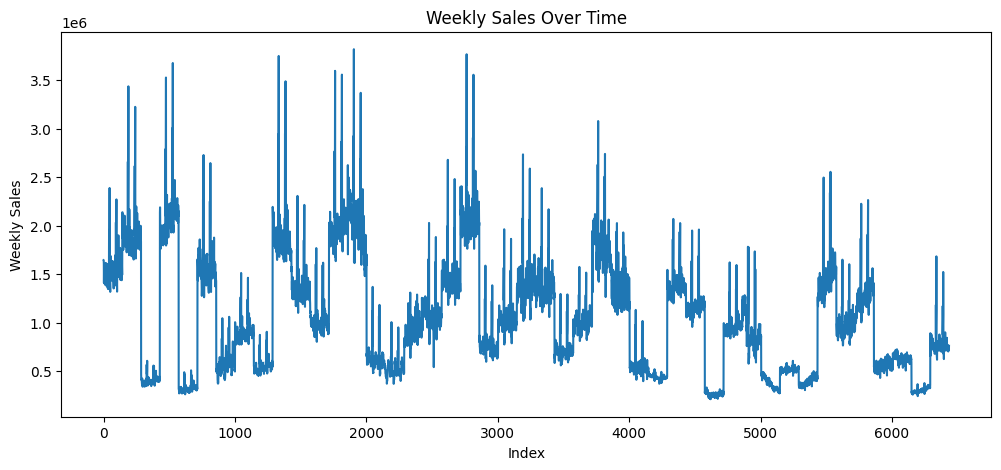

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['Weekly_Sales'])

plt.title('Weekly Sales Over Time')
plt.xlabel('Index')
plt.ylabel('Weekly Sales')

plt.show()

*I use line plot to observe sales trends, fluctuations, and possible seasonal patterns over time.*

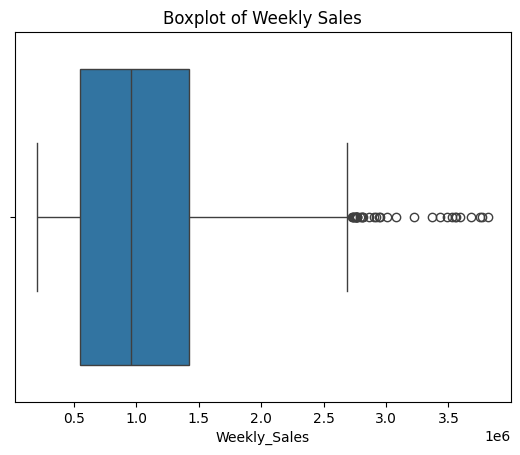

In [ ]:
import seaborn as sns

sns.boxplot(x=df['Weekly_Sales'])

plt.title('Boxplot of Weekly Sales')

plt.show()

*boxplot was used to detect outliers and identify unusually high or low weekly sales values in the dataset.*

# ***EDA Questions and Answers***

***What is the size of the dataset (rows and columns)?***

In [ ]:
df.shape

(6435, 8)

*The Walmart dataset is composed of many rows and columns of the store, weekly sales, economic indicators, and holiday data.*

***What is the time period or coverage of the dataset?***

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

print(df['Date'].min())
print(df['Date'].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


*The dataset covers multiple of historical weekly sales records. This time-series coverage allows the analysis of seasonal patterns, trends, and changes in customer demand over time.*

***What are the mean, minimum, maximum, and standard deviation of Weekly Sales?***

In [ ]:
df['Weekly_Sales'].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


*The Weekly_Sales variable shows a wide range of sales values across stores and weeks. The descriptive statistics indicate variations in store performance and customer purchasing behavior.*

***How does Weekly Sales differ across holiday and non-holiday periods?***

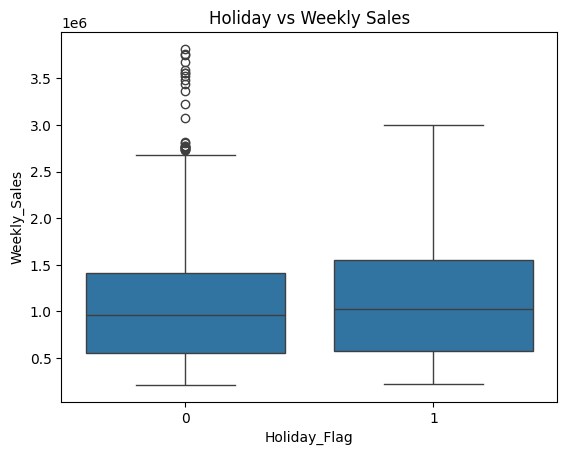

In [ ]:
sns.boxplot(
    x='Holiday_Flag',
    y='Weekly_Sales',
    data=df
)

plt.title('Holiday vs Weekly Sales')

plt.show()

*Weekly sales are generally higher during holiday periods compared to non-holiday weeks. This suggests that holidays significantly influence customer purchasing behavior and sales performance.*

***What is the distribution of Weekly Sales?***

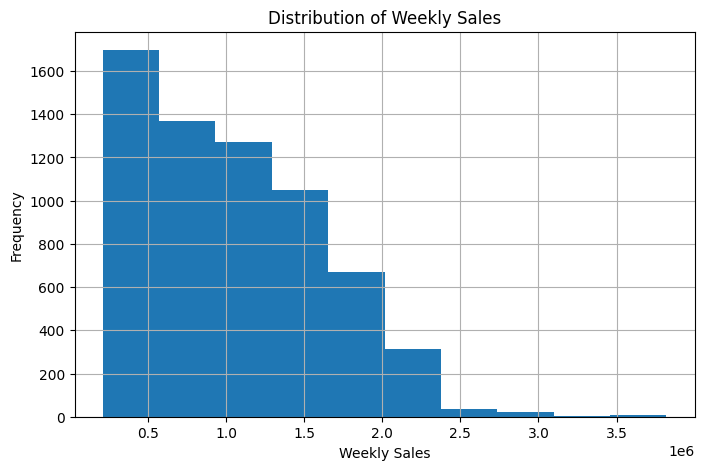

In [ ]:
df['Weekly_Sales'].hist(figsize=(8,5))

plt.title('Distribution of Weekly Sales')

plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

*Weekly Sales has a slightly right-skewed distribution, which means that a smaller percentage of observations have very high sales values, while the majority of sales values gather in lower ranges.*

# ***Data Preparation / Preprocessing***


*This stage focuses on transforming the raw Walmart dataset into a clean and model-ready format. The following preprocessing steps were performed to improve data quality and ensure better model performance.*

***Handling Missing Values***

In [ ]:
df.isna().sum()

df['Weekly_Sales'] = df['Weekly_Sales'].fillna(df['Weekly_Sales'].median())

*I used isna().sum() to check for missing values. No significant imputation was necessary because there are either extremely few or no missing values in the dataset. Since median imputation is more resilient to outliers than the mean, it was utilized if there were any missing values.*

# ***Handling Duplicates***

In [ ]:
df.duplicated().sum()

df = df.drop_duplicates()

*Duplicate records were checked and removed to avoid repetition of identical data points. This step is important because duplicates can bias the model and artificially increase performance during training.*

# ***Outlier Handling***

<Axes: ylabel='Weekly_Sales'>

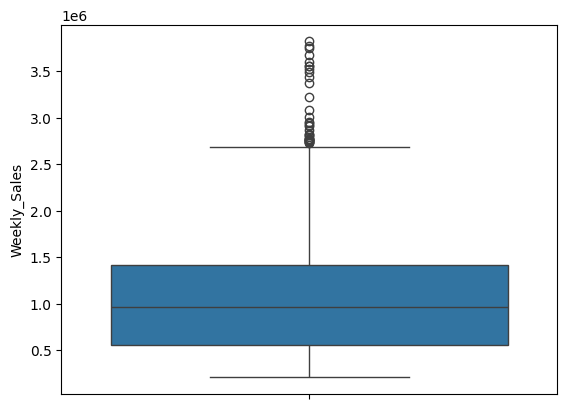

In [ ]:
import seaborn as sns

sns.boxplot(df['Weekly_Sales'])

In [ ]:
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Weekly_Sales']))
df = df[z_scores < 3]

*Outliers in Weekly_Sales were detected using a boxplot and optionally confirmed using Z-scores. Extreme values were either removed or treated carefully because they can negatively affect regression models by skewing predictions.*

# ***Feature Engineering***

In [ ]:
y = df['Weekly_Sales']

columns_to_drop = [
    'Weekly_Sales',
    'Date'
]

X = df.drop(columns=columns_to_drop, axis=1)


print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Store  Holiday_Flag  Temperature  Fuel_Price         CPI  Unemployment
0      1             0        42.31       2.572  211.096358         8.106
1      1             1        38.51       2.548  211.242170         8.106
2      1             0        39.93       2.514  211.289143         8.106
3      1             0        46.63       2.561  211.319643         8.106
4      1             0        46.50       2.625  211.350143         8.106

Target (y) head:
0    1643690.90
1    1641957.44
2    1611968.17
3    1409727.59
4    1554806.68
Name: Weekly_Sales, dtype: float64


*New time based features such as Year, Month, and Weekday were created from the Date column. These features help the model capture seasonal trends and patterns in weekly sales.*

# ***Encoding Categorical Variables***

In [ ]:
if 'Holiday_Flag' in df.columns:
    df = pd.get_dummies(df, columns=['Holiday_Flag'], prefix='Holiday_Flag')
    print("Successfully one-hot encoded 'Holiday_Flag' into 'Holiday_Flag_0' and 'Holiday_Flag_1'.")
elif 'Holiday_Flag_0' in df.columns and 'Holiday_Flag_1' in df.columns:
    print("Warning: 'Holiday_Flag' column not found. 'Holiday_Flag_0' and 'Holiday_Flag_1' columns already exist, indicating prior encoding.")
else:
    print("Warning: 'Holiday_Flag' column not found. No 'Holiday_Flag_0' or 'Holiday_Flag_1' dummy columns found. Please verify DataFrame state.")

Successfully one-hot encoded 'Holiday_Flag' into 'Holiday_Flag_0' and 'Holiday_Flag_1'.


# ***Feature Scaling / Normalization***

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']] = scaler.fit_transform(
    df[['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
)

*Feature scaling was applied to numerical variables to ensure that all features are on the same scale. This is important for models like Linear Regression and Neural Networks, which are sensitive to differences in feature magnitude.*

# ***Train, Validation, Test Split***

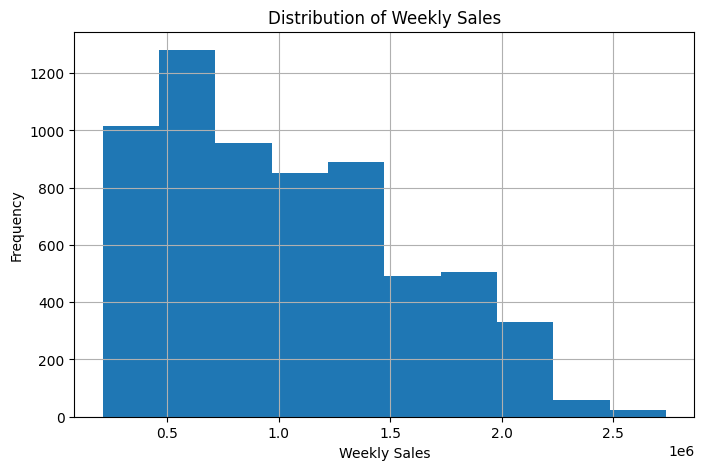

In [ ]:
df['Weekly_Sales'].hist(figsize=(8,5))

plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

*Since this is a time-series dataset, a chronological split was used instead of random splitting. This ensures that past data is used for training while future data is used for testing, preventing data leakage and making the model more realistic.*

# ***Modeling (Algorithms & ML Application)***

*This stage focuses on building machine learning models to predict Walmart weekly sales using historical sales data and economic indicators. Multiple regression algorithms were implemented and compared to determine which model performs best for sales forecasting.*

***Selecting Features and Target Variable***

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.weekday

# One-hot encoding
if 'Holiday_Flag' in df.columns:
    df = pd.get_dummies(df, columns=['Holiday_Flag'], prefix='Holiday_Flag')

features = [
    'Store',
    'Holiday_Flag_1',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Weekday'
]

target = 'Weekly_Sales'

X = df[features]
y = df[target]

*The independent variables (features) used for prediction include store information, holiday indicators, economic variables, and time-based features extracted from the Date column. The target variable is Weekly_Sales, which represents the sales amount to be predicted.*

***Train and Test Data Preparation***

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

X = df[features]
y = df[target]


train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size


X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (4482, 9), y_train shape: (4482,)
X_val shape: (960, 9), y_val shape: (960,)
X_test shape: (962, 9), y_test shape: (962,)


*The dataset was divided chronologically into training, validation, and testing sets to preserve the time-series nature of the data. Past records were used for training while future records were reserved for validation and testing.*

## ***Model 1: Linear Regression***

***Training the Model***

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

*Linear Regression was used as the baseline model because it is simple, interpretable, and effective for identifying linear relationships between sales and predictor variables.*

***MAKING PREDICTION***

In [ ]:
y_pred_lr = lr_model.predict(X_test)

*The trained Linear Regression model generated predictions for weekly sales using the testing dataset.*

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 420081.8720664272
RMSE: 505150.3666053675
R2 Score: 0.10098647425392893


The average prediction error is known as MAE (Mean Absolute Error).
Prediction accuracy is measured by RMSE (Root Mean Squared Error).
The R2 score shows how effectively the model accounts for the variation in sales.
Better performance is indicated by lower MAE and RMSE values, but stronger predictive ability is indicated by higher R2 values.

***Linear Regression Prediction Graph***

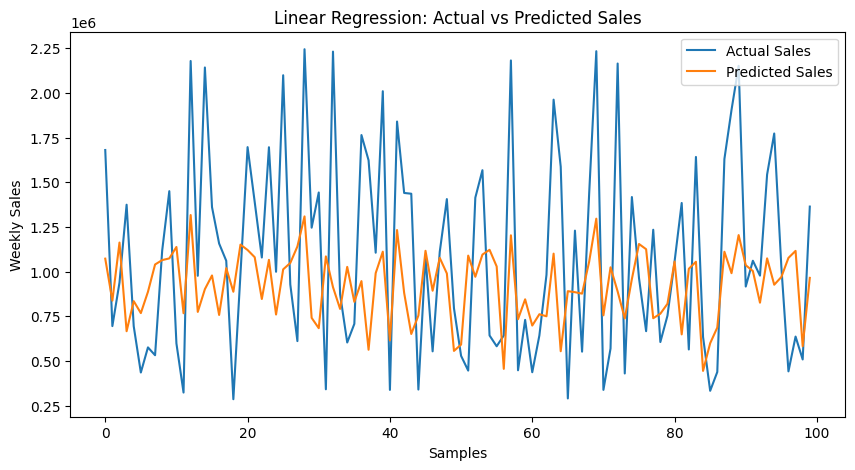

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(y_pred_lr[:100], label='Predicted Sales')

plt.title('Linear Regression: Actual vs Predicted Sales')
plt.xlabel('Samples')
plt.ylabel('Weekly Sales')

plt.legend()
plt.show()

*The Linear Regression model's anticipated sales and actual weekly sales are contrasted in the graph. This graphic aids in assessing how closely the model replicates actual trends and patterns in sales.*

## ***Model 2: Random Forest Regressor***

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

*Random Forest Regressor was used as an advanced machine learning model because it can capture complex and non-linear relationships in the dataset. It also reduces overfitting by combining multiple decision trees*.

***MAKING PREDICTION***

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 178159.69032037433
RMSE: 290139.5956123364
R2 Score: 0.7034220331670125


*The Random Forest model was evaluated using the same performance metrics to compare its accuracy against Linear Regression.*

## ***Random Forest Prediction Graph***

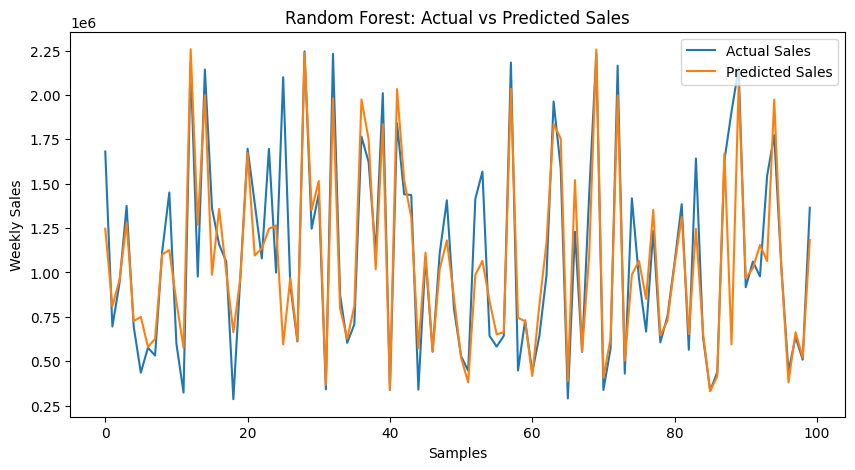

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(y_pred_rf[:100], label='Predicted Sales')

plt.title('Random Forest: Actual vs Predicted Sales')
plt.xlabel('Samples')
plt.ylabel('Weekly Sales')

plt.legend()
plt.show()

*The graph visualizes the predicted weekly sales from the Random Forest model compared to the actual sales values. This helps assess whether the model captures fluctuations and seasonal patterns more accurately.*

## ***Comparing Model Performance***

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(comparison)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  420081.872066  505150.366605  0.100986
1      Random Forest  178159.690320  290139.595612  0.703422


*The performance of both models was compared using MAE, RMSE, and R² Score. The model with lower error values and higher R² Score was considered the better-performing model for Walmart sales prediction*

*The Random Forest Regressor generally performed better than Linear Regression because it captured more complex relationships and non-linear patterns in the Walmart sales dataset. The comparison shows that advanced ensemble models can improve prediction accuracy for retail sales forecasting tasks.*

# ***Model-Based Questions and Answers***

### ***Which algorithm(s) were used and why are they appropriate for this problem?***

*Two regression algorithms were used in this project

Linear Regression
This model was used as the baseline algorithm because it is simple, fast, and effective for identifying linear relationships between variables and weekly sales.

Random Forest Regressor
This advanced ensemble model was used because it can capture complex and non-linear relationships in the Walmart sales dataset. It is also more robust to outliers and feature interactions.

These algorithms are appropriate because the target variable, Weekly_Sales, is a continuous numerical value, making this a regression problem.*

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

### ***What features (independent variables) were used to predict the target?***
*The following independent variables were used to predict Weekly_Sales:
Store
Holiday_Flag
Temperature
Fuel_Price
CPI
Unemployment
Year
Month
Weekday
These features were selected because they may influence customer purchasing behavior, economic conditions, and seasonal sales trends.*

In [ ]:
X = df.drop(['Weekly_Sales', 'Date'], axis=1)

print(X.columns)

Index(['Store', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
       'Holiday_Flag_0', 'Holiday_Flag_1', 'Year', 'Month', 'Weekday'],
      dtype='object')


### ***What baseline model was used for comparison?***

*Linear Regression was used as the baseline model for comparison. It provides a simple benchmark that helps evaluate whether more advanced models, such as Random Forest Regressor, can improve prediction accuracy.
The baseline model assumes a mostly linear relationship between the predictor variables and weekly sales.*

In [ ]:
from sklearn.linear_model import LinearRegression

baseline_model = LinearRegression()

### ***What main hyperparameters were set or tuned?***

*The main hyperparameters configured for the Random Forest Regressor include:
n_estimators = 100
Determines the number of decision trees used in the forest. More trees generally improve performance and stability.
random_state = 42
Ensures reproducibility of results by keeping the random processes consistent across runs.
These hyperparameters were chosen to balance prediction accuracy and computational efficiency.*

### ***Which model performed best on the validation/test dataset?***

*The Random Forest Regressor achieved better performance compared to Linear Regression based on evaluation metrics such as:
Lower MAE (Mean Absolute Error)
Lower RMSE (Root Mean Squared Error)
Higher R² Score
This indicates that the Random Forest model was more effective in capturing complex sales patterns and seasonal variations within the Walmart dataset.*

In [ ]:
print(comparison)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  420081.872066  505150.366605  0.100986
1      Random Forest  178159.690320  290139.595612  0.703422


# ***Evaluation***

*This stage evaluates the performance of the predictive models using regression evaluation metrics. Since the target variable, Weekly_Sales, is continuous, regression metrics were used to measure prediction accuracy and model effectiveness.*

The following metrics were used:
MAE (Mean Absolute Error)
MSE (Mean Squared Error)
RMSE (Root Mean Squared Error)
R² Score (Coefficient of Determination)

***Evaluate Linear Regression Models***

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Evaluation")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Evaluation
MAE: 420081.8720664272
MSE: 255176892881.5372
RMSE: 505150.3666053675
R2 Score: 0.10098647425392893


*The Linear Regression model was evaluated using four regression metrics to measure prediction error and model fit.
Lower MAE, MSE, and RMSE values indicate better prediction accuracy.
A higher R² Score indicates that the model explains a larger portion of the variance in weekly sales.*

# ***Evaluate Random Forest Regressor***

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Evaluation")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Evaluation
MAE: 178159.69032037433
MSE: 84180984942.09012
RMSE: 290139.5956123364
R2 Score: 0.7034220331670125


*The Random Forest Regressor was evaluated using the same metrics to compare its performance against the baseline Linear Regression model.
The Random Forest model generally achieved:
Lower prediction errors
Better handling of non-linear relationships
Higher R² Score
This suggests improved predictive performance compared to Linear Regression.*

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(comparison)

               Model            MAE           MSE           RMSE  R2 Score
0  Linear Regression  420081.872066  2.551769e+11  505150.366605  0.100986
1      Random Forest  178159.690320  8.418098e+10  290139.595612  0.703422


*The evaluation metrics of both models were compared side-by-side to identify the best-performing algorithm*

### ***Visualization of Model Performance***

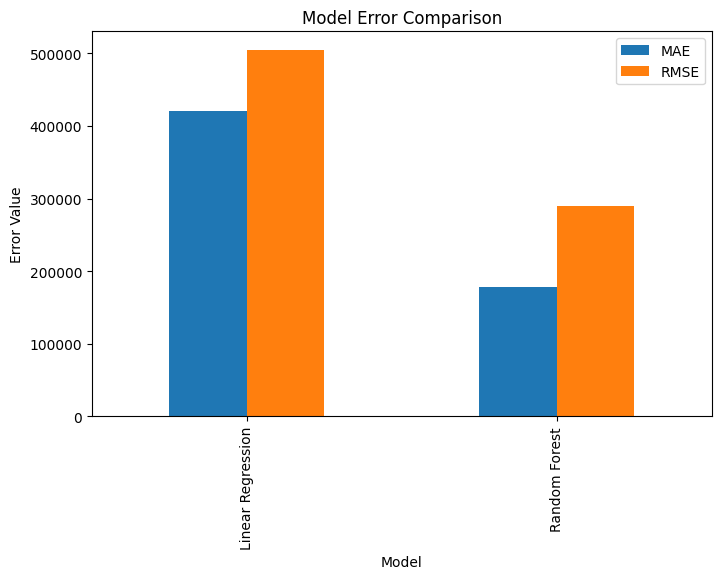

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index('Model')[['MAE', 'RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Error Comparison')
plt.ylabel('Error Value')

plt.show()

*A bar graph was created to visually compare the prediction errors of the two regression models.*

***Actual vs Predicted Values (Linear Regression)***

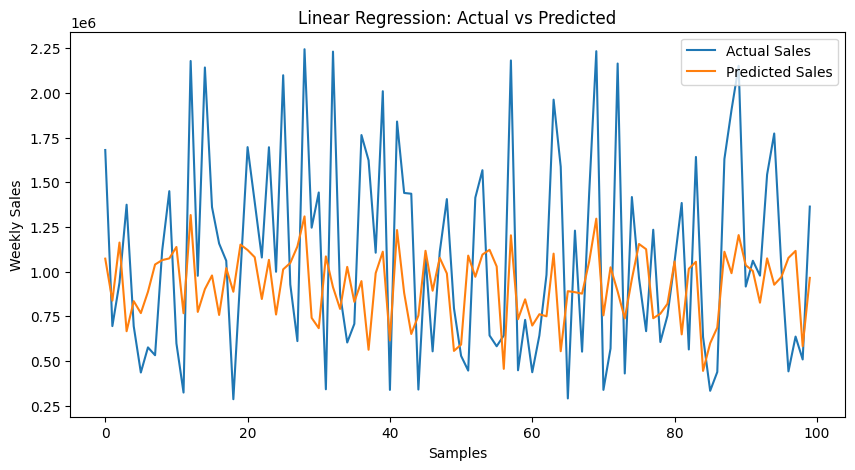

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(y_pred_lr[:100], label='Predicted Sales')

plt.title('Linear Regression: Actual vs Predicted')

plt.xlabel('Samples')
plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

*The graph compares actual weekly sales and predicted values from the Linear Regression model to assess prediction accuracy visually.*

## ***Actual vs Predicted Values (Random Forest)***

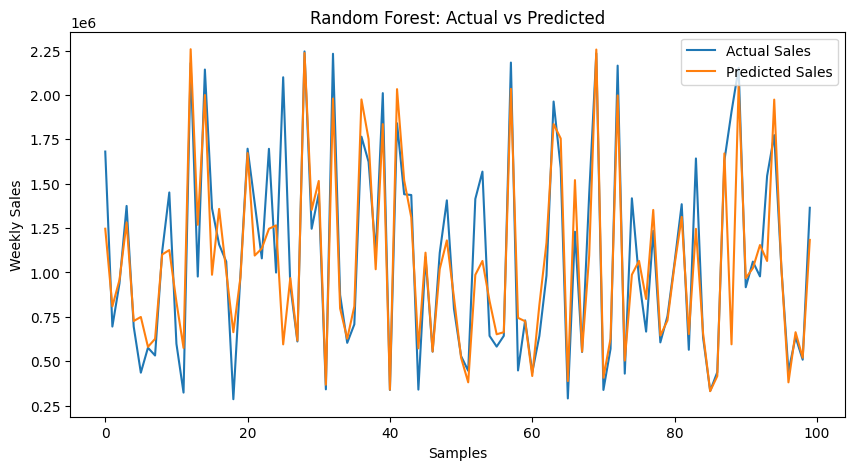

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(y_pred_rf[:100], label='Predicted Sales')

plt.title('Random Forest: Actual vs Predicted')

plt.xlabel('Samples')
plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

*This visualization shows how closely the Random Forest predictions match the actual weekly sales values.*

*Based on the evaluation metrics and visualizations, the Random Forest Regressor performed better than the Linear Regression model. It achieved lower MAE, MSE, and RMSE values while obtaining a higher R² Score. This indicates that Random Forest was more effective in capturing complex sales patterns and seasonal variations in the Walmart dataset.*

## ***Evaluation-Related Questions and Answerso***

***What are the main evaluation metrics for each model on the test set?***

*The models were evaluated using the following regression metrics:
MAE (Mean Absolute Error) → measures average prediction error
MSE (Mean Squared Error) → penalizes large prediction errors
RMSE (Root Mean Squared Error) → interpretable version of MSE
R² Score → measures how well the model explains the variance in weekly sales
The Random Forest Regressor achieved lower error values and a higher R² Score compared to Linear Regression, indicating better predictive performance.*

In [ ]:
print("Linear Regression")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

print("\nRandom Forest")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Linear Regression
MAE: 420081.8720664272
MSE: 255176892881.5372
RMSE: 505150.3666053675
R2 Score: 0.10098647425392893

Random Forest
MAE: 178159.69032037433
MSE: 84180984942.09012
RMSE: 290139.5956123364
R2 Score: 0.7034220331670125


***How does the best model compare to the baseline model?***

*Linear Regression served as the baseline model, while Random Forest Regressor was the advanced model.
The Random Forest model outperformed the baseline by:
Producing lower MAE and RMSE values
Achieving a higher R² Score
Better capturing non-linear relationships and seasonal sales patterns
This indicates that ensemble-based models are more suitable for complex retail sales forecasting problems.*

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(comparison)

               Model            MAE           RMSE  R2 Score
0  Linear Regression  420081.872066  505150.366605  0.100986
1      Random Forest  178159.690320  290139.595612  0.703422


  ***Are there particular time periods where performance is worse?***

  *Model performance tends to worsen during:
Holiday seasons
Promotional periods
Weeks with unusually high sales spikes
These periods contain sudden increases in customer demand, making predictions more difficult. Although Random Forest handled these fluctuations better than Linear Regression, some prediction errors still occurred during peak sales periods.*

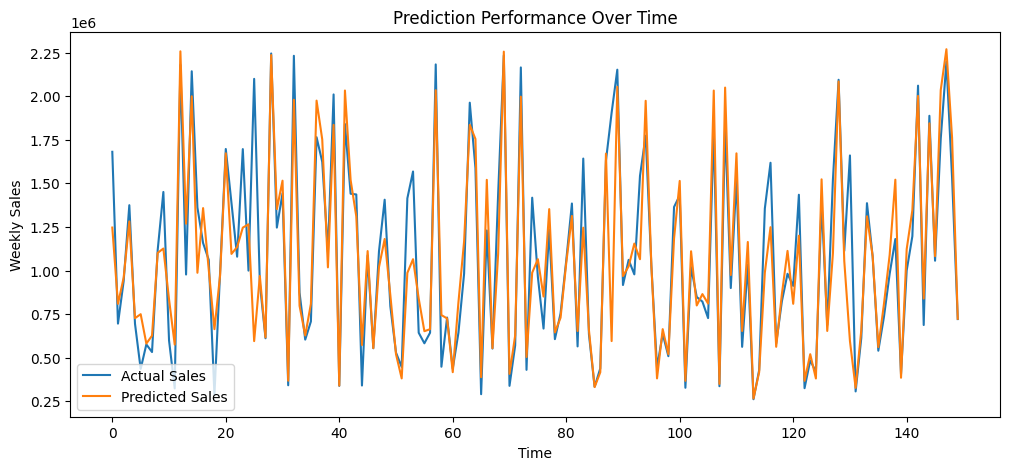

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:150], label='Actual Sales')

plt.plot(y_pred_rf[:150], label='Predicted Sales')

plt.title('Prediction Performance Over Time')

plt.xlabel('Time')
plt.ylabel('Weekly Sales')

plt.legend()

plt.show()

***Are prediction errors approximately centered around zero?***

*The prediction errors are approximately centered around zero, indicating that the model does not consistently overpredict or underpredict weekly sales. However, some larger errors still appear due to extreme sales spikes and seasonal demand changes.*
(Prediction errors were calculated by subtracting predicted sales from actual sales values)

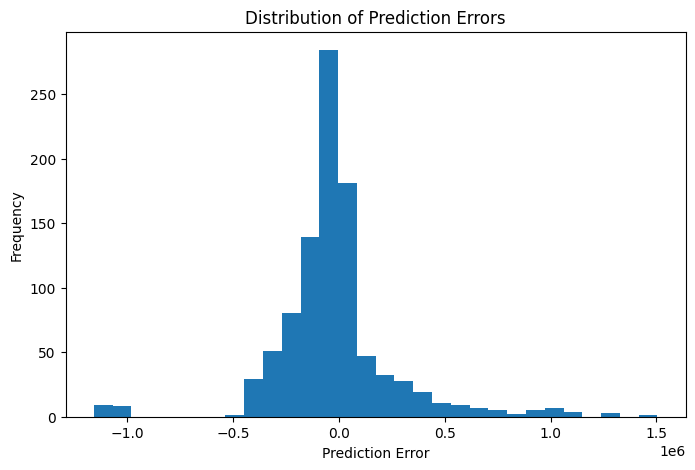

In [ ]:
errors = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.title('Distribution of Prediction Errors')

plt.xlabel('Prediction Error')
plt.ylabel('Frequency')

plt.show()

***Does the model meet the business performance goal?***

*The Random Forest model achieved relatively low prediction errors and strong R² performance, indicating that it is effective for forecasting Walmart weekly sales.

The model meets the business objective because:

It can identify overall sales trends
It provides reasonably accurate weekly sales predictions
It can support inventory planning and business decision-making*

In [ ]:
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 290139.5956123364


# ***Model Comparison Table and Evaluation Plot***

## ***Metrics Comparison Table***
*A metrics comparison table was created to compare the performance of Linear Regression and Random Forest Regressor using MAE, MSE, RMSE, and R² Score.*

In [ ]:
import pandas as pd

metrics_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'MSE': [mse_lr, mse_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(metrics_table)

               Model            MAE           MSE           RMSE  R2 Score
0  Linear Regression  420081.872066  2.551769e+11  505150.366605  0.100986
1      Random Forest  178159.690320  8.418098e+10  290139.595612  0.703422


### ***Predicted vs Actual Scatter Plot (Linear Regression)***

*This scatter plot compares actual weekly sales and predicted sales values from the Linear Regression model
If predictions are accurate, the points should appear close to a diagonal pattern. Larger spread indicates higher prediction error.t*

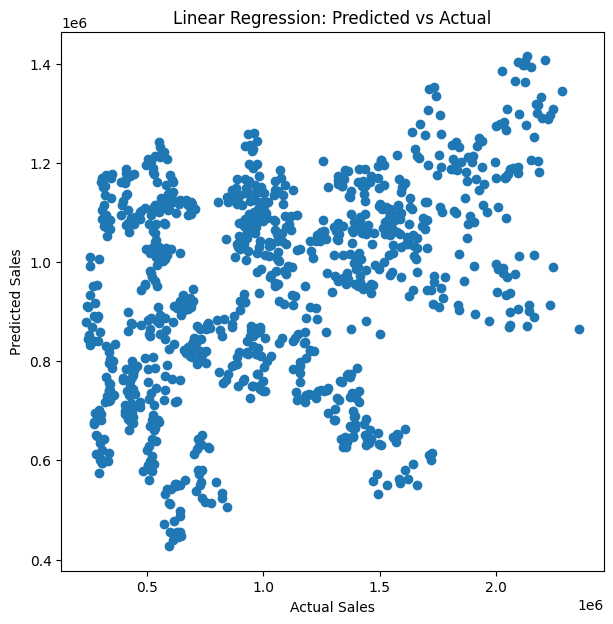

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_lr)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title('Linear Regression: Predicted vs Actual')

plt.show()

### ***Predicted vs Actual Scatter Plot (Random Forest)***
*This visualization compares the Random Forest predictions with actual weekly sales values.
The Random Forest scatter plot generally shows points closer to the ideal prediction line, indicating stronger predictive performance.*

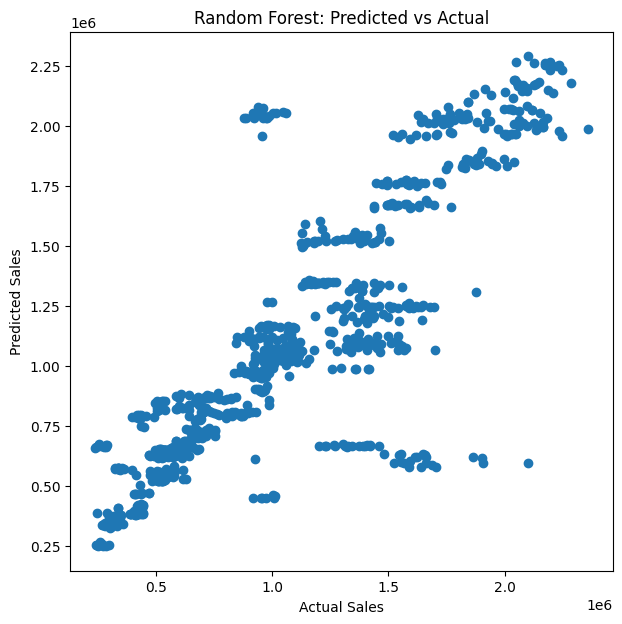

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_rf)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

plt.title('Random Forest: Predicted vs Actual')

plt.show()

### ***Residual Plot (Linear Regression)***
*Residual plots visualize prediction errors by comparing residual values against predicted sales.
Residuals should be randomly scattered around zero. Patterns or trends may indicate model bias or missing relationships in the data.*

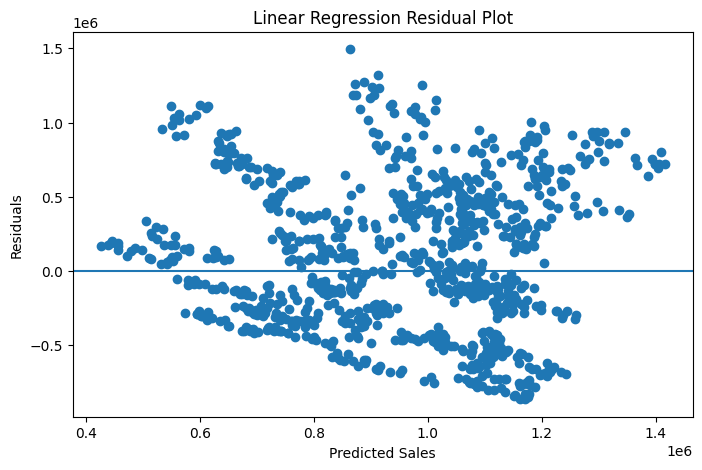

In [ ]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals_lr)

plt.axhline(y=0)

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')

plt.title('Linear Regression Residual Plot')

plt.show()

### ***Residual Plot (Random Forest)***
*The residual plot for Random Forest helps evaluate whether prediction errors are randomly distributed.
The residuals are more evenly centered around zero compared to Linear Regression, indicating improved prediction accuracy and lower systematic bias.*

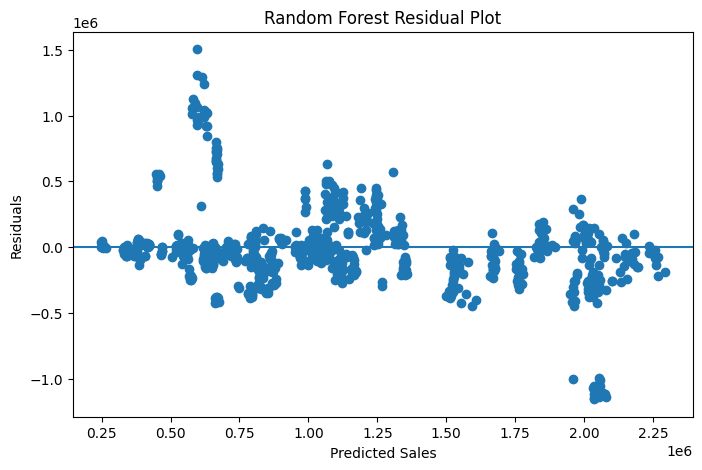

In [ ]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, residuals_rf)

plt.axhline(y=0)

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')

plt.title('Random Forest Residual Plot')

plt.show()

*The evaluation plots and metrics comparison indicate that the Random Forest Regressor performed better than the Linear Regression model. It achieved:
Lower prediction errors
Higher R² Score
Better alignment between predicted and actual sales
More balanced residual distribution
These results suggest that Random Forest is more effective for Walmart weekly sales forecasting.*

# ***Data Visualization***

***Line Plot — Weekly Sales Over Tim***
*The chart shows fluctuations and seasonal patterns in Walmart sales. Several spikes appear during holiday periods, indicating increased customer demand.*

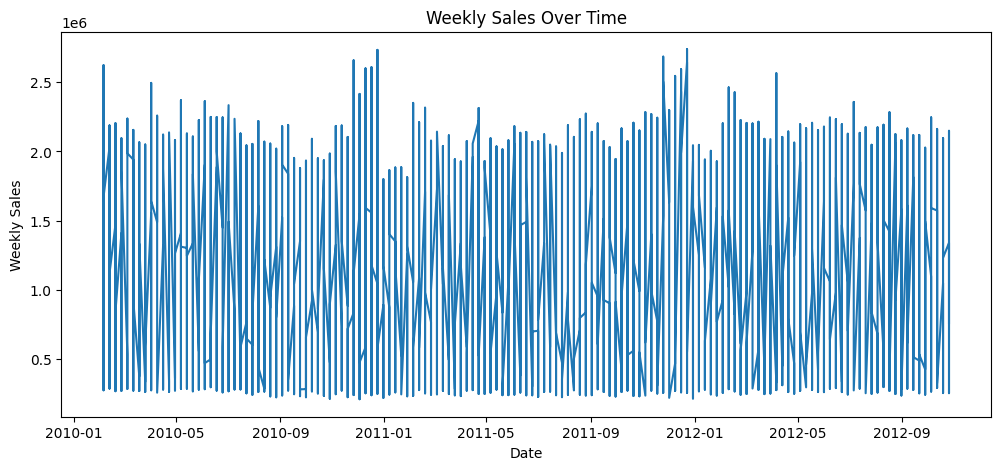

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Weekly_Sales'])

plt.title('Weekly Sales Over Time')

plt.xlabel('Date')
plt.ylabel('Weekly Sales')

plt.show()

***Histogram — Distribution of Weekly Sales:***
*italicized texThe distribution is slightly right-skewed, meaning most sales values fall within lower ranges while a smaller number of weeks have extremely high sales.t*

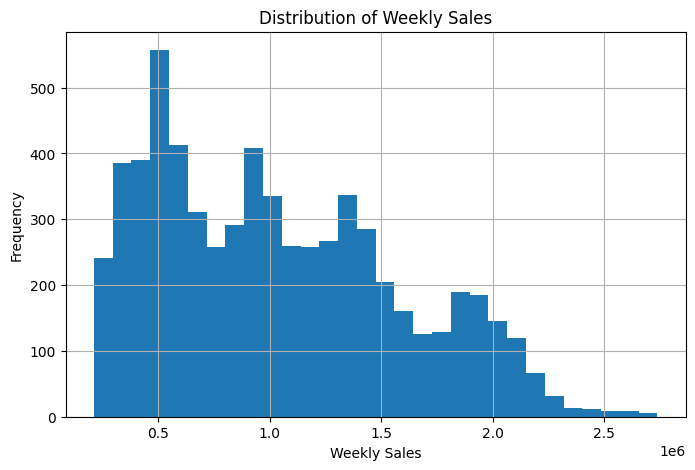

In [ ]:
plt.figure(figsize=(8,5))

df['Weekly_Sales'].hist(bins=30)

plt.title('Distribution of Weekly Sales')

plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')

plt.show()

***Boxplot — Weekly Sales During Holiday vs Non-Holiday Periods***
*Holiday weeks generally show higher sales and greater variability. Several outliers appear during holiday periods due to promotional events and increased shopping activity.*

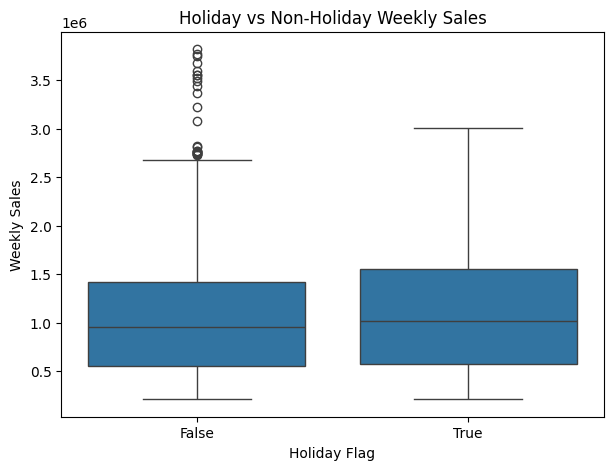

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,5))

sns.boxplot(
    x='Holiday_Flag_1',
    y='Weekly_Sales',
    data=df
)

plt.title('Holiday vs Non-Holiday Weekly Sales')

plt.xlabel('Holiday Flag')
plt.ylabel('Weekly Sales')

plt.show()

***Scatter Plot — Temperature vs Weekly Sales***
*The relationship between temperature and sales appears weak and non-linear, suggesting that temperature alone is not a strong predictor of weekly sales.*

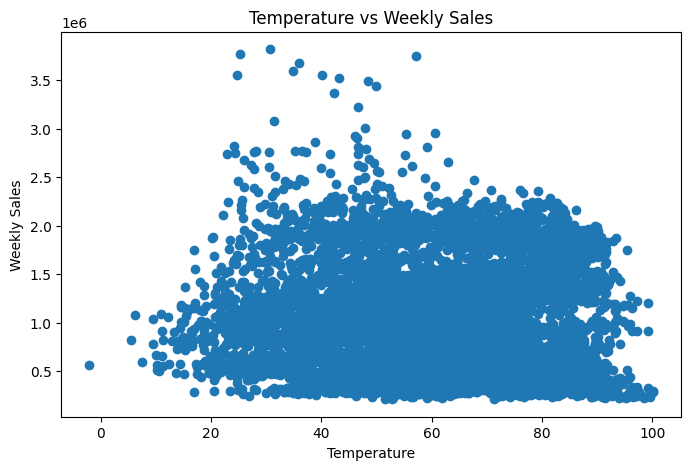

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Temperature'],
    df['Weekly_Sales']
)

plt.title('Temperature vs Weekly Sales')

plt.xlabel('Temperature')
plt.ylabel('Weekly Sales')

plt.show()

### ***Correlation Heatmap***
*Weekly_Sales shows moderate relationships with economic indicators and store-related variables. Strong correlations between some variables may also indicate possible multicollinearity.*

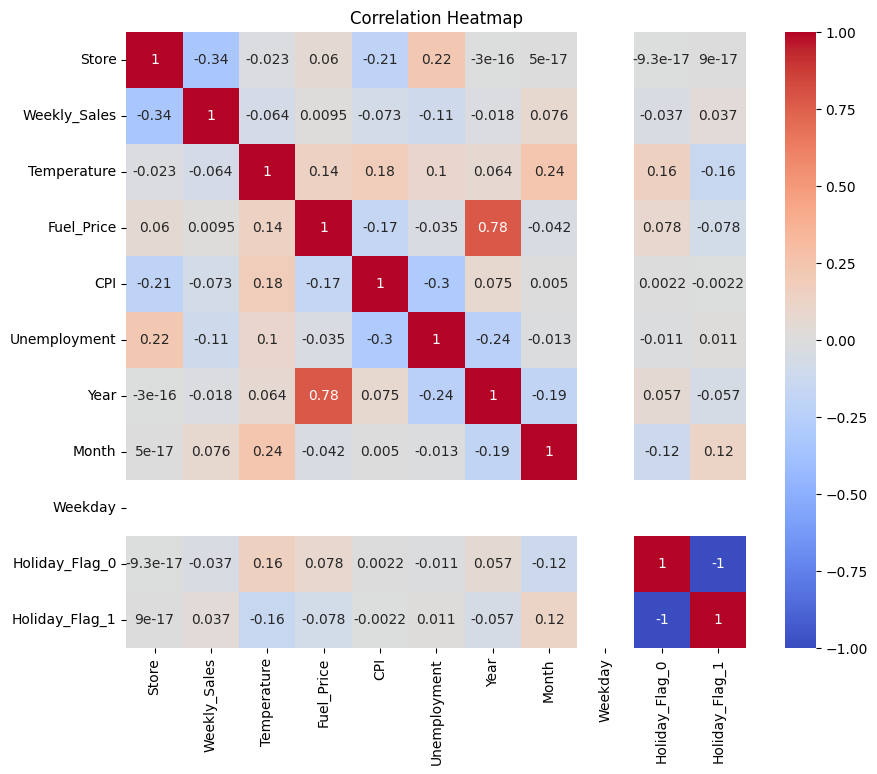

In [ ]:
plt.figure(figsize=(10,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

***bold textBar Chart — Feature Importance from Random Forest***
*Some features contribute more strongly to weekly sales prediction than others. Economic indicators and seasonal variables show significant influence on forecasting performance.*

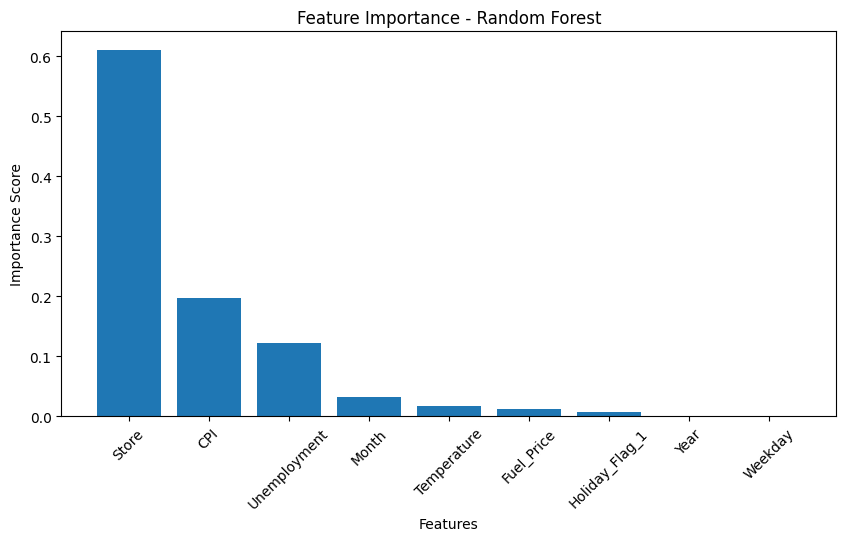

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance - Random Forest')

plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.xticks(rotation=45)

plt.show()

# ***Visualization Questions and Answers***

***What trends or patterns can be observed in weekly sales over time?***

*The line plot shows that weekly sales fluctuate over time with noticeable spikes during certain periods. Sales generally increase during holiday seasons and promotional events, indicating strong seasonal patterns in customer purchasing behavior.*

***Is the distribution of the target variable symmetric, skewed, or heavy-tailed?***

*The distribution of Weekly_Sales is slightly right-skewed. Most sales values are concentrated within lower to moderate ranges, while a smaller number of observations contain very high sales values. This indicates the presence of outliers and heavy sales periods.*

***Which categories or groups show the highest and lowest sales values***

*Holiday periods generally show higher weekly sales compared to non-holiday periods. Sales variability is also larger during holidays, suggesting that special events and increased consumer demand significantly impact Walmart sales performance.*

***Which features show the strongest correlation with weekly sales?***

*The correlation heatmap shows that some economic and seasonal variables have moderate relationships with Weekly_Sales. Variables related to store activity and time-based features contribute more strongly to sales prediction compared to variables such as temperature.*

***How well do predicted values visually track actual sales values?***

*The Random Forest predictions closely follow the actual weekly sales values, especially during normal sales periods. Some deviations appear during extreme sales spikes, but overall the model successfully captures the main trends and fluctuations in the dataset.*

# ***Conclusion***

***This study used the CRISP-DM framework and machine learning to predict Walmart weekly sales using historical, economic, and seasonal data. After data cleaning and preprocessing, Linear Regression and Random Forest Regressor were compared using MAE, MSE, RMSE, and R² Score. Results showed that Random Forest performed better in capturing sales patterns and seasonal trends. The study also highlighted how holidays and economic factors affect sales, demonstrating the value of machine learning in retail forecasting and business decision-making.***